In [1]:
from __future__ import annotations
import hashlib, json, re, unicodedata
from pathlib import Path
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from IPython.display import display
import matplotlib.pyplot as plt
from huggingface_hub import dataset_info, hf_hub_download
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline

SEED = 42
RUN_CLEANLAB = False
SHORT_LEN = 12
REPO = "Cleanlab/amazon-reviews"
OUT = Path("processed")
OUT.mkdir(exist_ok=True)
quarantine, issues = [], []


In [2]:
ds = dataset_info(REPO)
REVISION = ds.sha
train_path = hf_hub_download(REPO, "train.csv", repo_type="dataset")
test_path = hf_hub_download(REPO, "test.csv", repo_type="dataset")
train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)
n_test_raw = len(test_raw)
input_hashes = {
    "train.csv": hashlib.sha256(Path(train_path).read_bytes()).hexdigest(),
    "test.csv": hashlib.sha256(Path(test_path).read_bytes()).hexdigest(),
}


In [3]:
test_raw.to_csv(OUT / "test_raw.csv", index=False)
train_work = train_raw.copy()
test_clean = test_raw.copy()


In [4]:
src_cols = ["review_text", "label"]
assert list(train_work.columns) == src_cols, list(train_work.columns)
assert list(test_clean.columns) == src_cols, list(test_clean.columns)
assert pd.api.types.is_string_dtype(train_work["review_text"]) or train_work["review_text"].dtype == object
assert pd.api.types.is_string_dtype(train_work["label"]) or train_work["label"].dtype == object
assert pd.api.types.is_string_dtype(test_clean["review_text"]) or test_clean["review_text"].dtype == object
assert pd.api.types.is_string_dtype(test_clean["label"]) or test_clean["label"].dtype == object


In [5]:
train_work["split_source"] = "train"
train_work["source_row_id"] = range(len(train_work))
test_clean["split_source"] = "test"
test_clean["source_row_id"] = range(len(test_clean))


In [6]:
print({"revision": REVISION, "train": train_work.shape, "test": test_clean.shape})
print(train_work.dtypes)
display(train_work.head())
display(train_work["review_text"].str.len().describe().to_frame("char_len"))


{'revision': 'bca513e6ecd76a4051dfb80445ff0b0083c6be35', 'train': (5000, 4), 'test': (1000, 4)}
review_text        str
label              str
split_source       str
source_row_id    int64
dtype: object


,review_text,label,split_source,source_row_id
0,Excellent product! I love reading through the magazine and learning about the cool new products out there and the cool programs!,positive,train,0
1,"If you into gaming, into the latest PC tech info, like reviews of hardware rated 1 thru 10, chomp PC builds, get this rag. @ $12 bucks for 2 years its worth every penny",positive,train,1
2,Great Mag..!!,positive,train,2
3,"Extremely similar to GQ, same publisher. You aren't going to get anything from this magazine that you don't get from GQ. Similar to GQ, lots of ads and minimal content.",positive,train,3
4,it is great read and great ideas for today's men .. great price.. buy it today.. go for it :),positive,train,4


,char_len
count,5000.000000
mean,92.524000
std,47.672167
min,9.000000
25%,49.000000
50%,97.000000
75%,132.000000
max,179.000000


,n,len_mean,len_median
label,,,
negative,1908,96.730608,101.0
positive,3092,89.928202,93.0


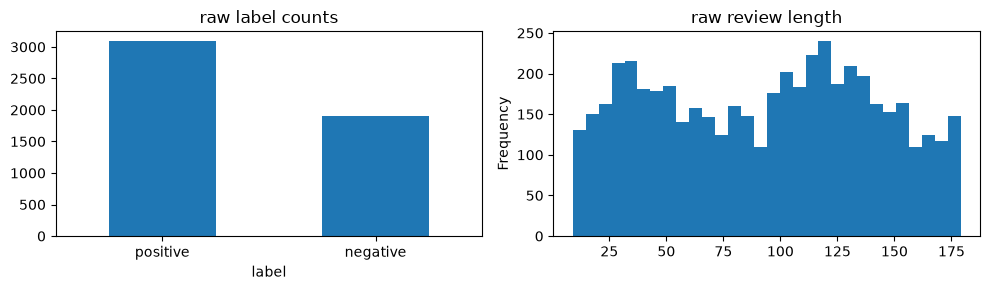

In [7]:
raw_eda = train_work.assign(char_len=train_work["review_text"].str.len())
display(raw_eda.groupby("label").agg(n=("review_text", "size"), len_mean=("char_len", "mean"), len_median=("char_len", "median")))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
raw_eda["label"].value_counts().plot(kind="bar", ax=ax[0], title="raw label counts", rot=0)
raw_eda["char_len"].plot(kind="hist", bins=30, ax=ax[1], title="raw review length")
plt.tight_layout(); fig.savefig(OUT / "eda_raw.png", dpi=150, bbox_inches="tight"); plt.show()


In [8]:
train_work["label"] = train_work["label"].astype(str).str.strip().str.lower()
test_clean["label"] = test_clean["label"].astype(str).str.strip().str.lower()
allowed = {"positive", "negative"}
bad_tr = ~train_work["label"].isin(allowed)
bad_te = ~test_clean["label"].isin(allowed)
for df, m in ((train_work, bad_tr), (test_clean, bad_te)):
    for r in df.loc[m, ["split_source", "source_row_id"]].itertuples(index=False):
        quarantine.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "invalid_label", "action": "removed"})
train_work = train_work.loc[~bad_tr].copy()
test_clean = test_clean.loc[~bad_te].copy()


In [9]:
for df in (train_work, test_clean):
    df["review_text_clean"] = df["review_text"].fillna("").map(lambda s: re.sub(r"\s+", " ", unicodedata.normalize("NFKC", str(s))).strip())


In [10]:
empty_tr = train_work["review_text_clean"].eq("") | train_work["label"].isna()
empty_te = test_clean["review_text_clean"].eq("") | test_clean["label"].isna()
for df, m in ((train_work, empty_tr), (test_clean, empty_te)):
    for r in df.loc[m, ["split_source", "source_row_id"]].itertuples(index=False):
        quarantine.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "empty_or_missing", "action": "removed"})
train_work = train_work.loc[~empty_tr].copy()
test_clean = test_clean.loc[~empty_te].copy()


In [11]:
for df in (train_work, test_clean):
    short = df["review_text_clean"].str.len() < SHORT_LEN
    for r in df.loc[short, ["split_source", "source_row_id"]].itertuples(index=False):
        issues.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "short_review", "action": "retained_flagged"})


In [12]:
nlab = train_work.groupby("review_text_clean")["label"].nunique()
conflict_txt = set(nlab[nlab > 1].index)
c_tr = train_work["review_text_clean"].isin(conflict_txt)
for r in train_work.loc[c_tr, ["source_row_id"]].itertuples(index=False):
    quarantine.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "label_conflict", "action": "removed"})
train_work = train_work.loc[~c_tr].copy()


In [13]:
nlab_te = test_clean.groupby("review_text_clean")["label"].nunique()
conflict_te = set(nlab_te[nlab_te > 1].index)
for r in test_clean.loc[test_clean["review_text_clean"].isin(conflict_te), ["source_row_id"]].itertuples(index=False):
    issues.append({"split_source": "test", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "label_conflict", "action": "retained_flagged"})


In [14]:
merged = train_work.merge(test_clean[["review_text_clean", "label"]], on="review_text_clean", suffixes=("_tr", "_te"))
cross_conf = set(merged.loc[merged["label_tr"] != merged["label_te"], "review_text_clean"])
xc = train_work["review_text_clean"].isin(cross_conf)
for r in train_work.loc[xc, ["source_row_id"]].itertuples(index=False):
    quarantine.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "cross_split_label_conflict", "action": "removed"})
train_work = train_work.loc[~xc].copy()


In [15]:
dup_tr = train_work.duplicated("review_text_clean", keep="first")
for r in train_work.loc[dup_tr, ["source_row_id"]].itertuples(index=False):
    quarantine.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "duplicate", "action": "removed"})
train_work = train_work.loc[~dup_tr].copy()


In [16]:
dup_te = test_clean.duplicated("review_text_clean", keep="first")
for r in test_clean.loc[dup_te, ["source_row_id"]].itertuples(index=False):
    issues.append({"split_source": "test", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "duplicate", "action": "retained_flagged"})


In [17]:
ov = train_work["review_text_clean"].isin(set(test_clean["review_text_clean"]))
for r in train_work.loc[ov, ["source_row_id"]].itertuples(index=False):
    quarantine.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "cross_split_duplicate", "action": "removed"})
train_work = train_work.loc[~ov].copy()


In [18]:
train_clean, val_clean = train_test_split(train_work, test_size=0.2, random_state=SEED, stratify=train_work["label"])
train_clean, val_clean = train_clean.copy(), val_clean.copy()


In [19]:
s_tr, s_va, s_te = set(train_clean["review_text_clean"]), set(val_clean["review_text_clean"]), set(test_clean["review_text_clean"])
assert not (s_tr & s_va), "train/val overlap"
assert not (s_tr & s_te), "train/test overlap"
assert not (s_va & s_te), "val/test overlap"


In [20]:
dist = {
    "train_clean": train_clean["label"].value_counts().to_dict(),
    "val_clean": val_clean["label"].value_counts().to_dict(),
    "test_clean": test_clean["label"].value_counts().to_dict(),
}
print(dist)
print({"N_test_raw": n_test_raw, "N_test_clean": len(test_clean)})
display(pd.DataFrame(dist).fillna(0).astype(int))


{'train_clean': {'positive': 2474, 'negative': 1526}, 'val_clean': {'positive': 618, 'negative': 382}, 'test_clean': {'positive': 553, 'negative': 447}}
{'N_test_raw': 1000, 'N_test_clean': 1000}


,train_clean,val_clean,test_clean
positive,2474,618,553
negative,1526,382,447


label,negative,positive
split,,
test,447,553
train,1526,2474
val,382,618


stage  reason      
etl    short_review    57
Name: flagged, dtype: int64

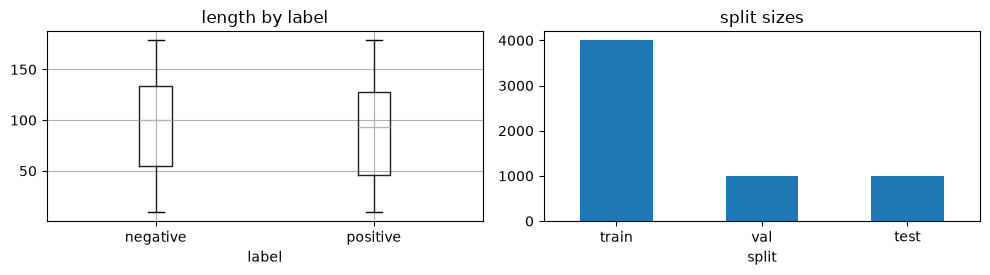

In [21]:
clean_eda = pd.concat([train_clean.assign(split="train"), val_clean.assign(split="val"), test_clean.assign(split="test")], ignore_index=True)
clean_eda = clean_eda.assign(char_len=clean_eda["review_text_clean"].str.len())
display(clean_eda.groupby(["split", "label"]).size().unstack(fill_value=0))
if quarantine: display(pd.DataFrame(quarantine).groupby(["stage", "reason"]).size().rename("removed"))
if issues: display(pd.DataFrame(issues).groupby(["stage", "reason"]).size().rename("flagged"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
clean_eda.boxplot(column="char_len", by="label", ax=ax[0]); ax[0].set_title("length by label"); ax[0].set_xlabel("label")
clean_eda["split"].value_counts().plot(kind="bar", ax=ax[1], title="split sizes", rot=0)
plt.suptitle(""); plt.tight_layout(); fig.savefig(OUT / "eda_clean.png", dpi=150, bbox_inches="tight"); plt.show()


In [22]:
test_primary = test_clean.copy()
test_dedup = test_clean.drop_duplicates("review_text_clean", keep="first").copy()


In [23]:
keep = ["review_text", "review_text_clean", "label", "split_source", "source_row_id"]
train_clean[keep].to_csv(OUT / "train_clean.csv", index=False)
val_clean[keep].to_csv(OUT / "val_clean.csv", index=False)
test_clean[keep].to_csv(OUT / "test_clean.csv", index=False)
test_primary[keep].to_csv(OUT / "test_primary.csv", index=False)
test_dedup[keep].to_csv(OUT / "test_dedup.csv", index=False)
pd.DataFrame(quarantine).to_csv(OUT / "quarantine.csv", index=False)
pd.DataFrame(issues).to_csv(OUT / "issues.csv", index=False)
report = {
    "revision": REVISION,
    "seed": SEED,
    "input_hashes": input_hashes,
    "config": {"short_len": SHORT_LEN, "run_cleanlab": RUN_CLEANLAB, "val_size": 0.2},
    "counts": {"train_clean": len(train_clean), "val_clean": len(val_clean), "test_clean": len(test_clean), "test_primary": len(test_primary), "test_dedup": len(test_dedup), "quarantine": len(quarantine), "issues": len(issues)},
    "N_test_raw": n_test_raw,
    "N_test_clean": len(test_clean),
    "test_row_delta_reasons": [q for q in quarantine if q["split_source"] == "test"],
    "distributions": dist,
    "invariants": {"train_val": 0, "train_test": 0, "val_test": 0},
}
(OUT / "validation_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
assert train_clean["label"].isin(allowed).all() and val_clean["label"].isin(allowed).all() and test_clean["label"].isin(allowed).all()
assert train_clean["review_text_clean"].notna().all() and (train_clean["review_text_clean"] != "").all()


In [24]:
train_dev = train_clean.copy()
enc = {"negative": 0, "positive": 1}
train_dev["y"] = train_dev["label"].map(enc)
val_clean["y"] = val_clean["label"].map(enc)
test_primary["y"] = test_primary["label"].map(enc)
test_dedup["y"] = test_dedup["label"].map(enc)


In [25]:
if RUN_CLEANLAB:
    from cleanlab.filter import find_label_issues
    baseline = Pipeline([("tfidf", TfidfVectorizer(lowercase=True)), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    pred_probs = cross_val_predict(baseline, train_dev["review_text_clean"], train_dev["y"], cv=cv, method="predict_proba")
    issue_mask = find_label_issues(labels=train_dev["y"].to_numpy(), pred_probs=pred_probs)
    suspected = train_dev.loc[issue_mask, ["source_row_id", "review_text_clean", "label"]]
    display(suspected.head(20))
    for r in train_dev.loc[issue_mask, ["source_row_id"]].itertuples(index=False):
        issues.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "cleanlab", "reason": "suspected_label_issue", "action": "retained_flagged"})
    pd.DataFrame(issues).to_csv(OUT / "issues.csv", index=False)
else:
    print("RUN_CLEANLAB=False; skip data-quality loop")


RUN_CLEANLAB=False; skip data-quality loop


In [26]:
candidates = {
    "tfidf_lr": Pipeline([("tfidf", TfidfVectorizer(lowercase=True, min_df=2)), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "tfidf_lr_balanced": Pipeline([("tfidf", TfidfVectorizer(lowercase=True, min_df=2)), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))]),
    "tfidf_ngram_lr": Pipeline([("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))]),
}
val_scores = {}
fitted = {}
for name, pipe in candidates.items():
    model = clone(pipe)
    model.fit(train_dev["review_text_clean"], train_dev["y"])
    pred = model.predict(val_clean["review_text_clean"])
    val_scores[name] = f1_score(val_clean["y"], pred, average="macro")
    fitted[name] = model
    print(name, val_scores[name], classification_report(val_clean["y"], pred, target_names=["negative", "positive"]))
best_name = max(val_scores, key=val_scores.get)
display(pd.DataFrame({"f1_macro": val_scores}).sort_values("f1_macro", ascending=False))
print("selected", best_name, val_scores[best_name])


tfidf_lr 0.8076987122259572               precision    recall  f1-score   support

    negative       0.79      0.73      0.76       382
    positive       0.84      0.88      0.86       618

    accuracy                           0.82      1000
   macro avg       0.81      0.80      0.81      1000
weighted avg       0.82      0.82      0.82      1000

tfidf_lr_balanced 0.8312368282402529               precision    recall  f1-score   support

    negative       0.74      0.87      0.80       382
    positive       0.91      0.81      0.86       618

    accuracy                           0.84      1000
   macro avg       0.83      0.84      0.83      1000
weighted avg       0.85      0.84      0.84      1000

tfidf_ngram_lr 0.7955327126136946               precision    recall  f1-score   support

    negative       0.77      0.71      0.74       382
    positive       0.83      0.87      0.85       618

    accuracy                           0.81      1000
   macro avg       0.80      

,f1_macro
tfidf_lr_balanced,0.831237
tfidf_lr,0.807699
tfidf_ngram_lr,0.795533


selected tfidf_lr_balanced 0.8312368282402529


metrics_primary {'accuracy': 0.954, 'precision': 0.9570354325378756, 'recall': 0.9506899523040888, 'f1_macro': 0.953184282946052, 'confusion_matrix': [[411, 36], [10, 543]], 'class_counts': {'positive': 553, 'negative': 447}}
              precision    recall  f1-score   support

    negative       0.98      0.92      0.95       447
    positive       0.94      0.98      0.96       553

    accuracy                           0.95      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000

metrics_deduplicated {'accuracy': 0.954, 'precision': 0.9570354325378756, 'recall': 0.9506899523040888, 'f1_macro': 0.953184282946052, 'confusion_matrix': [[411, 36], [10, 543]], 'class_counts': {'positive': 553, 'negative': 447}}


,primary,deduplicated
accuracy,0.954,0.954
precision,0.957035,0.957035
recall,0.95069,0.95069
f1_macro,0.953184,0.953184


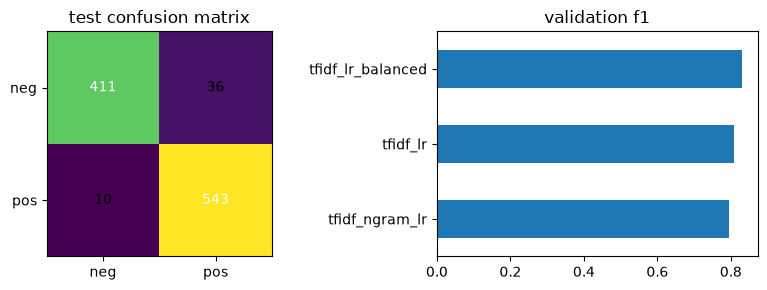

875

In [27]:
train_final = pd.concat([train_dev, val_clean], ignore_index=True)
selected = clone(candidates[best_name])
selected.fit(train_final["review_text_clean"], train_final["y"])
pred_primary = selected.predict(test_primary["review_text_clean"])
pred_dedup = selected.predict(test_dedup["review_text_clean"])
metrics_primary = {
    "accuracy": accuracy_score(test_primary["y"], pred_primary),
    "precision": precision_score(test_primary["y"], pred_primary, average="macro"),
    "recall": recall_score(test_primary["y"], pred_primary, average="macro"),
    "f1_macro": f1_score(test_primary["y"], pred_primary, average="macro"),
    "confusion_matrix": confusion_matrix(test_primary["y"], pred_primary).tolist(),
    "class_counts": test_primary["label"].value_counts().to_dict(),
}
metrics_deduplicated = {
    "accuracy": accuracy_score(test_dedup["y"], pred_dedup),
    "precision": precision_score(test_dedup["y"], pred_dedup, average="macro"),
    "recall": recall_score(test_dedup["y"], pred_dedup, average="macro"),
    "f1_macro": f1_score(test_dedup["y"], pred_dedup, average="macro"),
    "confusion_matrix": confusion_matrix(test_dedup["y"], pred_dedup).tolist(),
    "class_counts": test_dedup["label"].value_counts().to_dict(),
}
print("metrics_primary", metrics_primary)
print(classification_report(test_primary["y"], pred_primary, target_names=["negative", "positive"]))
print("metrics_deduplicated", metrics_deduplicated)
display(pd.DataFrame({"primary": metrics_primary, "deduplicated": metrics_deduplicated}).loc[["accuracy", "precision", "recall", "f1_macro"]])
cm = confusion_matrix(test_primary["y"], pred_primary)
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(cm); ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1]); ax[0].set_xticklabels(["neg", "pos"]); ax[0].set_yticklabels(["neg", "pos"])
for i in range(2):
    for j in range(2): ax[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
ax[0].set_title("test confusion matrix")
pd.DataFrame({"f1_macro": val_scores}).sort_values("f1_macro", ascending=True).plot(kind="barh", ax=ax[1], legend=False, title="validation f1")
plt.tight_layout(); fig.savefig(OUT / "eda_results.png", dpi=150, bbox_inches="tight"); plt.show()
(OUT / "metrics.json").write_text(json.dumps({"selected": best_name, "val_scores": val_scores, "metrics_primary": metrics_primary, "metrics_deduplicated": metrics_deduplicated}, indent=2), encoding="utf-8")
